<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_2_Data_Preprocessing_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark -q

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("DiabetesProgressionPrediction")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [ ]:
DATA_PATH = "/content/Diabetes (4).csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.show(5)

Total Rows: 1264171
Total Columns: 12
+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
| id|age|   sex|  bmi|    bp|    tc|  ldl|  hdl| tch|  ltg|   glu|progression|
+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
|  0| 22|  Male|20.33|106.25|140.89|-0.45|62.83|0.77|-0.54|130.98|      29.83|
|  1| 41|Female|25.99|132.23|129.64|-1.11|37.26|0.81| 1.64|151.19|      46.66|
|  2| 51|Female|32.76| 127.0|220.36|-1.69|49.56|0.41|-0.88|176.22|      59.97|
|  3| 26|  Male|35.87| 138.4|194.19|-0.04|55.57|0.45|-1.38|125.32|      42.44|
|  4| 42|Female| 21.5|122.33|275.79| 1.19|63.64|0.54|-0.69|184.72|      49.36|
+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
only showing top 5 rows


In [ ]:
print("Dataset Schema:")
df.printSchema()

print("\nFirst 5 Records:")
df.show(5)

print("\nStatistical Summary:")
df.describe().show()

Dataset Schema:
root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- bp: double (nullable = true)
 |-- tc: double (nullable = true)
 |-- ldl: double (nullable = true)
 |-- hdl: double (nullable = true)
 |-- tch: double (nullable = true)
 |-- ltg: double (nullable = true)
 |-- glu: double (nullable = true)
 |-- progression: double (nullable = true)


First 5 Records:
+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
| id|age|   sex|  bmi|    bp|    tc|  ldl|  hdl| tch|  ltg|   glu|progression|
+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
|  0| 22|  Male|20.33|106.25|140.89|-0.45|62.83|0.77|-0.54|130.98|      29.83|
|  1| 41|Female|25.99|132.23|129.64|-1.11|37.26|0.81| 1.64|151.19|      46.66|
|  2| 51|Female|32.76| 127.0|220.36|-1.69|49.56|0.41|-0.88|176.22|      59.97|
|  3| 26|  Male|35.87| 138.4|194.19|-0.04|55.57|0.45|-1.38|

In [ ]:
missing_values = df.select([
    F.sum(
        F.when(F.col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in df.columns
])

missing_values.show()

# Remove rows containing missing values
df_clean = df.dropna()

print("Rows after cleaning:", df_clean.count())

+---+---+---+---+---+---+---+---+---+---+---+-----------+
| id|age|sex|bmi| bp| tc|ldl|hdl|tch|ltg|glu|progression|
+---+---+---+---+---+---+---+---+---+---+---+-----------+
|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|          0|
+---+---+---+---+---+---+---+---+---+---+---+-----------+

Rows after cleaning: 1264171


In [ ]:
df_clean.printSchema()

root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- bp: double (nullable = true)
 |-- tc: double (nullable = true)
 |-- ldl: double (nullable = true)
 |-- hdl: double (nullable = true)
 |-- tch: double (nullable = true)
 |-- ltg: double (nullable = true)
 |-- glu: double (nullable = true)
 |-- progression: double (nullable = true)



In [ ]:
# Start again from the original dataset
clean_data = df.dropna()

# Convert Male/Female into numbers manually
clean_data = clean_data.withColumn(
    "sex_numeric",
    F.when(F.col("sex") == "Male", 1.0)
     .when(F.col("sex") == "Female", 0.0)
     .otherwise(None)
)

# Feature columns
feature_columns = [
    "age",
    "sex_numeric",
    "bmi",
    "bp",
    "tc",
    "ldl",
    "hdl",
    "tch",
    "ltg",
    "glu"
]

# Create feature vector
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(clean_data)

# Show the prepared data
data.select(
    "features",
    "progression"
).show(5, truncate=False)

+------------------------------------------------------------+-----------+
|features                                                    |progression|
+------------------------------------------------------------+-----------+
|[22.0,1.0,20.33,106.25,140.89,-0.45,62.83,0.77,-0.54,130.98]|29.83      |
|[41.0,0.0,25.99,132.23,129.64,-1.11,37.26,0.81,1.64,151.19] |46.66      |
|[51.0,0.0,32.76,127.0,220.36,-1.69,49.56,0.41,-0.88,176.22] |59.97      |
|[26.0,1.0,35.87,138.4,194.19,-0.04,55.57,0.45,-1.38,125.32] |42.44      |
|[42.0,0.0,21.5,122.33,275.79,1.19,63.64,0.54,-0.69,184.72]  |49.36      |
+------------------------------------------------------------+-----------+
only showing top 5 rows


In [ ]:
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())

Training Records: 1011467
Testing Records: 252704


In [ ]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="progression"
)

# Train the model
lr_model = lr.fit(train_data)

# Make predictions
lr_predictions = lr_model.transform(test_data)

# Show predictions
lr_predictions.select(
    "progression",
    "prediction"
).show(10, truncate=False)

print("Linear Regression model trained successfully!")

+-----------+------------------+
|progression|prediction        |
+-----------+------------------+
|59.97      |59.973028149789286|
|39.55      |39.55273180609335 |
|53.84      |53.838317889804976|
|41.11      |41.11194095784831 |
|50.64      |50.639521024477894|
|47.08      |47.077325418496116|
|29.53      |29.530131698354964|
|44.13      |44.128424345547025|
|55.8       |55.79753149527776 |
|60.28      |60.280523671835056|
+-----------+------------------+
only showing top 10 rows
Linear Regression model trained successfully!


In [ ]:
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="progression",
    maxDepth=6
)

# Train the model
dt_model = dt.fit(train_data)

# Make predictions
dt_predictions = dt_model.transform(test_data)

# Show predictions
dt_predictions.select(
    "progression",
    "prediction"
).show(10, truncate=False)

print("Decision Tree Regression model trained successfully!")

+-----------+------------------+
|progression|prediction        |
+-----------+------------------+
|59.97      |61.41170962103461 |
|39.55      |39.63624878207213 |
|53.84      |51.00380986901306 |
|41.11      |41.001671232876674|
|50.64      |53.309001870032695|
|47.08      |48.901175083934525|
|29.53      |27.66686331133114 |
|44.13      |47.08618983300595 |
|55.8       |56.136868384475605|
|60.28      |60.681847679368715|
+-----------+------------------+
only showing top 10 rows
Decision Tree Regression model trained successfully!


In [ ]:
# Create evaluators
rmse_evaluator = RegressionEvaluator(
    labelCol="progression",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="progression",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="progression",
    predictionCol="prediction",
    metricName="r2"
)

# Linear Regression scores
lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_mae = mae_evaluator.evaluate(lr_predictions)
lr_r2 = r2_evaluator.evaluate(lr_predictions)

# Decision Tree scores
dt_rmse = rmse_evaluator.evaluate(dt_predictions)
dt_mae = mae_evaluator.evaluate(dt_predictions)
dt_r2 = r2_evaluator.evaluate(dt_predictions)

# Display results
results = [
    ("Linear Regression", lr_rmse, lr_mae, lr_r2),
    ("Decision Tree", dt_rmse, dt_mae, dt_r2)
]

results_df = spark.createDataFrame(
    results,
    ["Model", "RMSE", "MAE", "R2"]
)

results_df.show(truncate=False)

+-----------------+---------------------+--------------------+------------------+
|Model            |RMSE                 |MAE                 |R2                |
+-----------------+---------------------+--------------------+------------------+
|Linear Regression|0.0028894012841601093|0.002502909795058038|0.9999999030016046|
|Decision Tree    |1.958333439467455    |1.5368079972016708  |0.95544236757767  |
+-----------------+---------------------+--------------------+------------------+



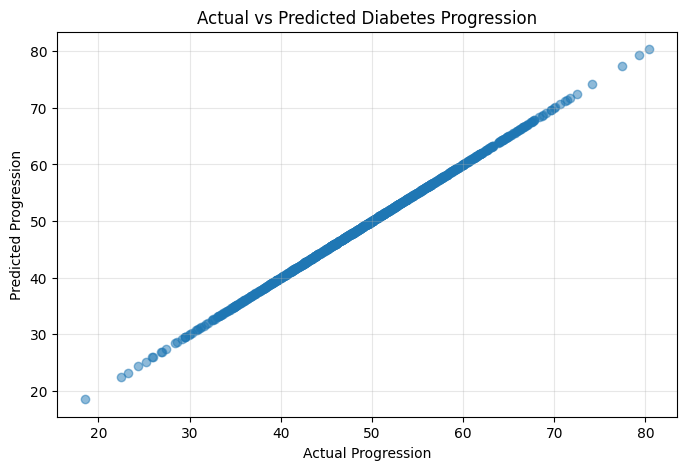

In [ ]:
# Prepare sample data for visualisation
plot_data = (
    lr_predictions
    .select("progression", "prediction")
    .limit(1000)
    .toPandas()
)

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_data["progression"],
    plot_data["prediction"],
    alpha=0.5
)

plt.title("Actual vs Predicted Diabetes Progression")
plt.xlabel("Actual Progression")
plt.ylabel("Predicted Progression")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
print("""
====================================================
WEEK 3 — DIABETES PROGRESSION PREDICTION
====================================================

PROJECT COMPLETED SUCCESSFULLY

Dataset:
• Large-scale diabetes dataset
• Patient health and clinical attributes
• Target variable: progression

DATA PROCESSING:
• PySpark DataFrames
• Data exploration and statistics
• Missing value handling
• Categorical data conversion
• Feature vector creation using VectorAssembler
• 80/20 train-test split

MACHINE LEARNING MODELS:
• Linear Regression
• Decision Tree Regression

MODEL EVALUATION:
• RMSE
• MAE
• R² Score
• Actual vs Predicted visualisation

CONCLUSION:
The diabetes dataset was successfully processed using
PySpark. Patient characteristics were transformed into
machine learning features and two regression models
were trained to predict diabetes progression.

The models were evaluated using RMSE, MAE and R²
metrics, allowing their predictive performance to be
compared effectively.

====================================================
WEEK 3 COMPLETE
====================================================
""")


WEEK 3 — DIABETES PROGRESSION PREDICTION

PROJECT COMPLETED SUCCESSFULLY

Dataset:
• Large-scale diabetes dataset
• Patient health and clinical attributes
• Target variable: progression

DATA PROCESSING:
• PySpark DataFrames
• Data exploration and statistics
• Missing value handling
• Categorical data conversion
• Feature vector creation using VectorAssembler
• 80/20 train-test split

MACHINE LEARNING MODELS:
• Linear Regression
• Decision Tree Regression

MODEL EVALUATION:
• RMSE
• MAE
• R² Score
• Actual vs Predicted visualisation

CONCLUSION:
The diabetes dataset was successfully processed using
PySpark. Patient characteristics were transformed into
machine learning features and two regression models
were trained to predict diabetes progression.

The models were evaluated using RMSE, MAE and R²
metrics, allowing their predictive performance to be
compared effectively.

WEEK 3 COMPLETE

